# Tabular Kaggle Project

Guideline for steps for the Kaggle Tabular Project. You will "turn in" a GitHub repository, modeled after [Project Template](https://github.com/UTA-DataScience/ProjectTempate) on the day of the final, Friday, May 1 at 11 – 1:30 pm. During the final period we will have about 5 minutes to go over your project and your results.

You can find a list of possible Tabular datasets here on [Excel File in Teams](https://mavsuta.sharepoint.com/:x:/r/teams/Course_2262_data_3402_001-tImyQiF6rCJKf/Shared%20Documents/General/TabularDatasets.xlsx?d=w4ae5174d4ac5455aa4a8f03e70918898&csf=1&web=1&e=Lqtpue). You are not limited to these datasets. If you find a Kaggle challenge not listed that you would like to attempt, please check with Dr. Farbin to make sure it is viable. Note that the requirement is that the data you use is tabular, meaning that it can be represented as a table, therefore excluding images, video, audio, and other more raw data formats as well as data that is more structure.  Note that Kaggle hosts datasets without well defined competition associated with them, which will require you to define the problem and assessment metrics. Please select datasets associated with competitions. 

Your first task is to select a challange / dataset. I would like everyone to come to Lecture on Wednesday April 8 with at least one dataset in mind. I will ask students who select datasets not from the provided list to share the links so we can evaluate the dataset in class.

This notebook outlines the steps you should follow. The file(s) in the GitHub repository should contain these steps. Note that you will be only considering classification projects. 

## Define Project

* Provide Project link.
* Short paragraph describing the challenge. 
* Briefly describe the data.


## Data Loading and Initial Look

* Load the data. 
* Count the number of rows (data points) and features.
* Any missing values? 
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values? 
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression: 
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.

## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


In [1]:
# Define Project

# Challenge Description: This project works with the Horse Colic dataset to predict the outcome (lived, died, or euthanized) for horses showing colic symptoms. Colic is a general term for abdominal pain in horses and can be life threatening. The task is a multi-class classification problem where the goal is to use clinical observations to predict the survival outcome.

# Data Description:The dataset has 299 rows (horses) and 28 columns (27 features plus the target). It contains a mix of numerical clinical measurements such as rectal temperature, pulse, packed cell volume, and total protein, along with categorical clinical observations like pain level, mucous membrane color, and abdominal distention. The target outcome has three classes: lived (about 178), died (about 77), and euthanized (about 44), which makes the problem moderately class imbalanced. Many of the features also have substantial missing values, with some exceeding 60%.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('horse.csv', encoding='latin-1')
print(f"Shape: {df.shape}")
print(f"Rows (data points): {df.shape[0]}")
print(f"Features: {df.shape[1] - 1}  (target = 'outcome')")
df.head()


Shape: (299, 28)
Rows (data points): 299
Features: 27  (target = 'outcome')


,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,no,adult,530101,38.5,66.0,28.0,cool,reduced,NaN,more_3_sec,...,45.0,8.4,NaN,NaN,died,no,11300,0,0,no
1,yes,adult,534817,39.2,88.0,20.0,NaN,NaN,pale_cyanotic,less_3_sec,...,50.0,85.0,cloudy,2.0,euthanized,no,2208,0,0,no
2,no,adult,530334,38.3,40.0,24.0,normal,normal,pale_pink,less_3_sec,...,33.0,6.7,NaN,NaN,lived,no,0,0,0,yes
3,yes,young,5290409,39.1,164.0,84.0,cold,normal,dark_cyanotic,more_3_sec,...,48.0,7.2,serosanguious,5.3,died,yes,2208,0,0,yes
4,no,adult,530255,37.3,104.0,35.0,NaN,NaN,dark_cyanotic,more_3_sec,...,74.0,7.4,NaN,NaN,died,no,4300,0,0,no


In [4]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
nasogastric_reflux_ph,246,82.3
abdomo_protein,198,66.2
abdomo_appearance,165,55.2
abdomen,118,39.5
nasogastric_reflux,106,35.5
nasogastric_tube,104,34.8
rectal_exam_feces,102,34.1
peripheral_pulse,69,23.1
rectal_temp,60,20.1
respiratory_rate,58,19.4


In [5]:
# Feature summary table: type, range/values, missing count, outliers (IQR rule for numerics)
rows = []
for col in df.columns:
    if col == 'outcome':
        continue
    missing_count = int(df[col].isnull().sum())

    if pd.api.types.is_numeric_dtype(df[col]):
        ftype = 'Numerical'
        vals = f"{df[col].min():.2f} to {df[col].max():.2f}"
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        n_out = int(((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum())
        outliers = str(n_out)
    else:
        ftype = 'Categorical'
        uniq = sorted(df[col].dropna().unique().astype(str).tolist())
        vals = ', '.join(uniq)
        outliers = 'N/A'

    rows.append({'Feature': col, 'Type': ftype, 'Values / Range': vals,
                 'Missing': missing_count, 'Outliers (IQR)': outliers})

summary = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 80)
summary

,Feature,Type,Values / Range,Missing,Outliers (IQR)
0,surgery,Categorical,"no, yes",0,N/A
1,age,Categorical,"adult, young",0,N/A
2,hospital_number,Numerical,518476.00 to 5305629.00,0,36
3,rectal_temp,Numerical,35.40 to 40.80,60,14
4,pulse,Numerical,30.00 to 184.00,24,5
5,respiratory_rate,Numerical,8.00 to 96.00,58,17
6,temp_of_extremities,Categorical,"cold, cool, normal, warm",56,N/A
7,peripheral_pulse,Categorical,"absent, increased, normal, reduced",69,N/A
8,mucous_membrane,Categorical,"bright_pink, bright_red, dark_cyanotic, normal_pink, pale_cyanotic, pale_pink",47,N/A
9,capillary_refill_time,Categorical,"3, less_3_sec, more_3_sec",32,N/A


Target class distribution:
outcome
lived         178
died           77
euthanized     44
Name: count, dtype: int64



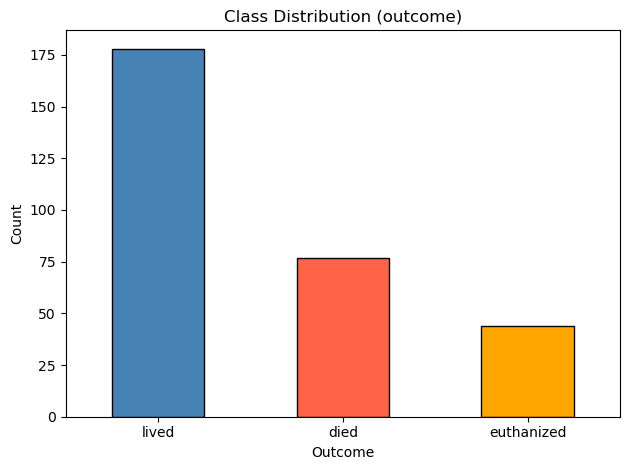


Target will be encoded later as: lived=0, died=1, euthanized=2


In [6]:
# Class imbalance check
print("Target class distribution:")
print(df['outcome'].value_counts())
print()

df['outcome'].value_counts().plot(kind='bar',
    color=['steelblue','tomato','orange'], edgecolor='black')
plt.title('Class Distribution (outcome)')
plt.xlabel('Outcome'); plt.ylabel('Count')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

print("\nTarget will be encoded later as: lived=0, died=1, euthanized=2")

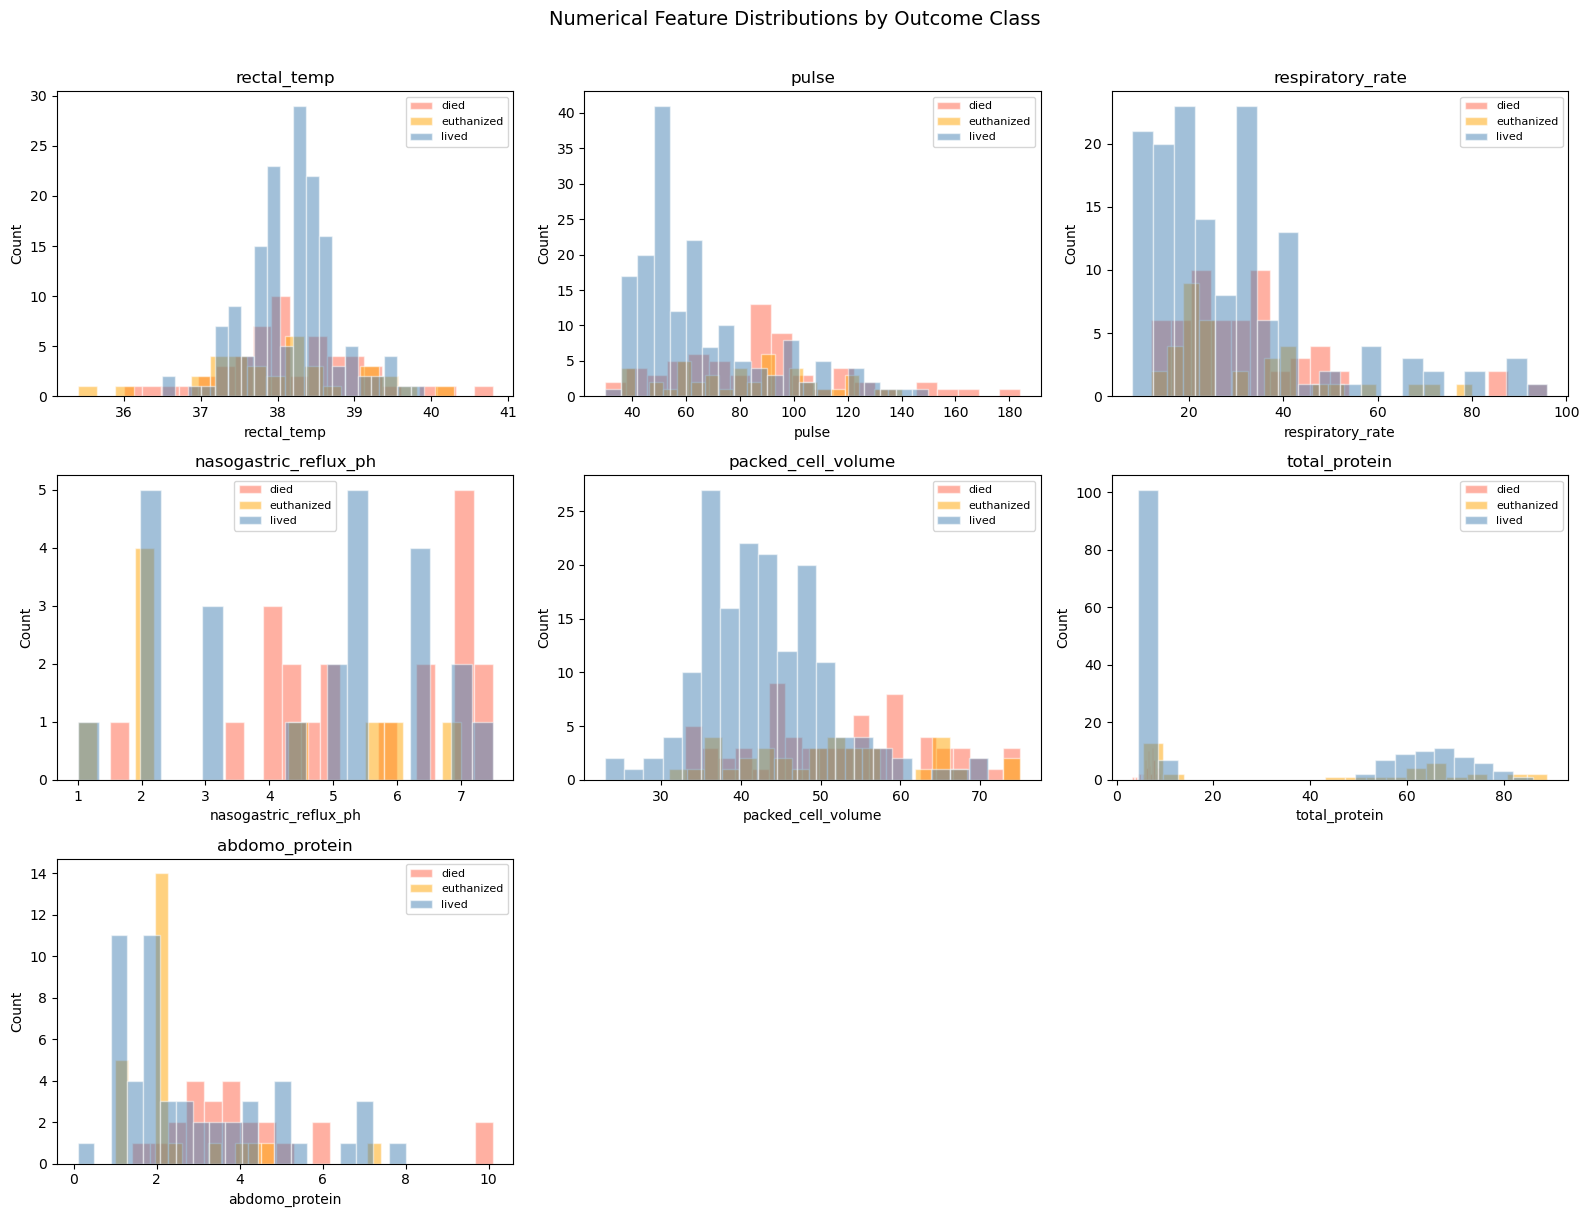

In [7]:
# Data Visualization

# For the multi-class target, the feature distribution across three outcome classes are compared.

# Histograms of numerical features by class
num_cols = ['rectal_temp', 'pulse', 'respiratory_rate', 'nasogastric_reflux_ph',
            'packed_cell_volume', 'total_protein', 'abdomo_protein']

colors = {'lived': 'steelblue', 'died': 'tomato', 'euthanized': 'orange'}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for outcome, grp in df.groupby('outcome'):
        vals = grp[col].dropna()
        ax.hist(vals, bins=20, alpha=0.5, label=outcome,
                color=colors[outcome], edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel(col); ax.set_ylabel('Count')
    ax.legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Outcome Class', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

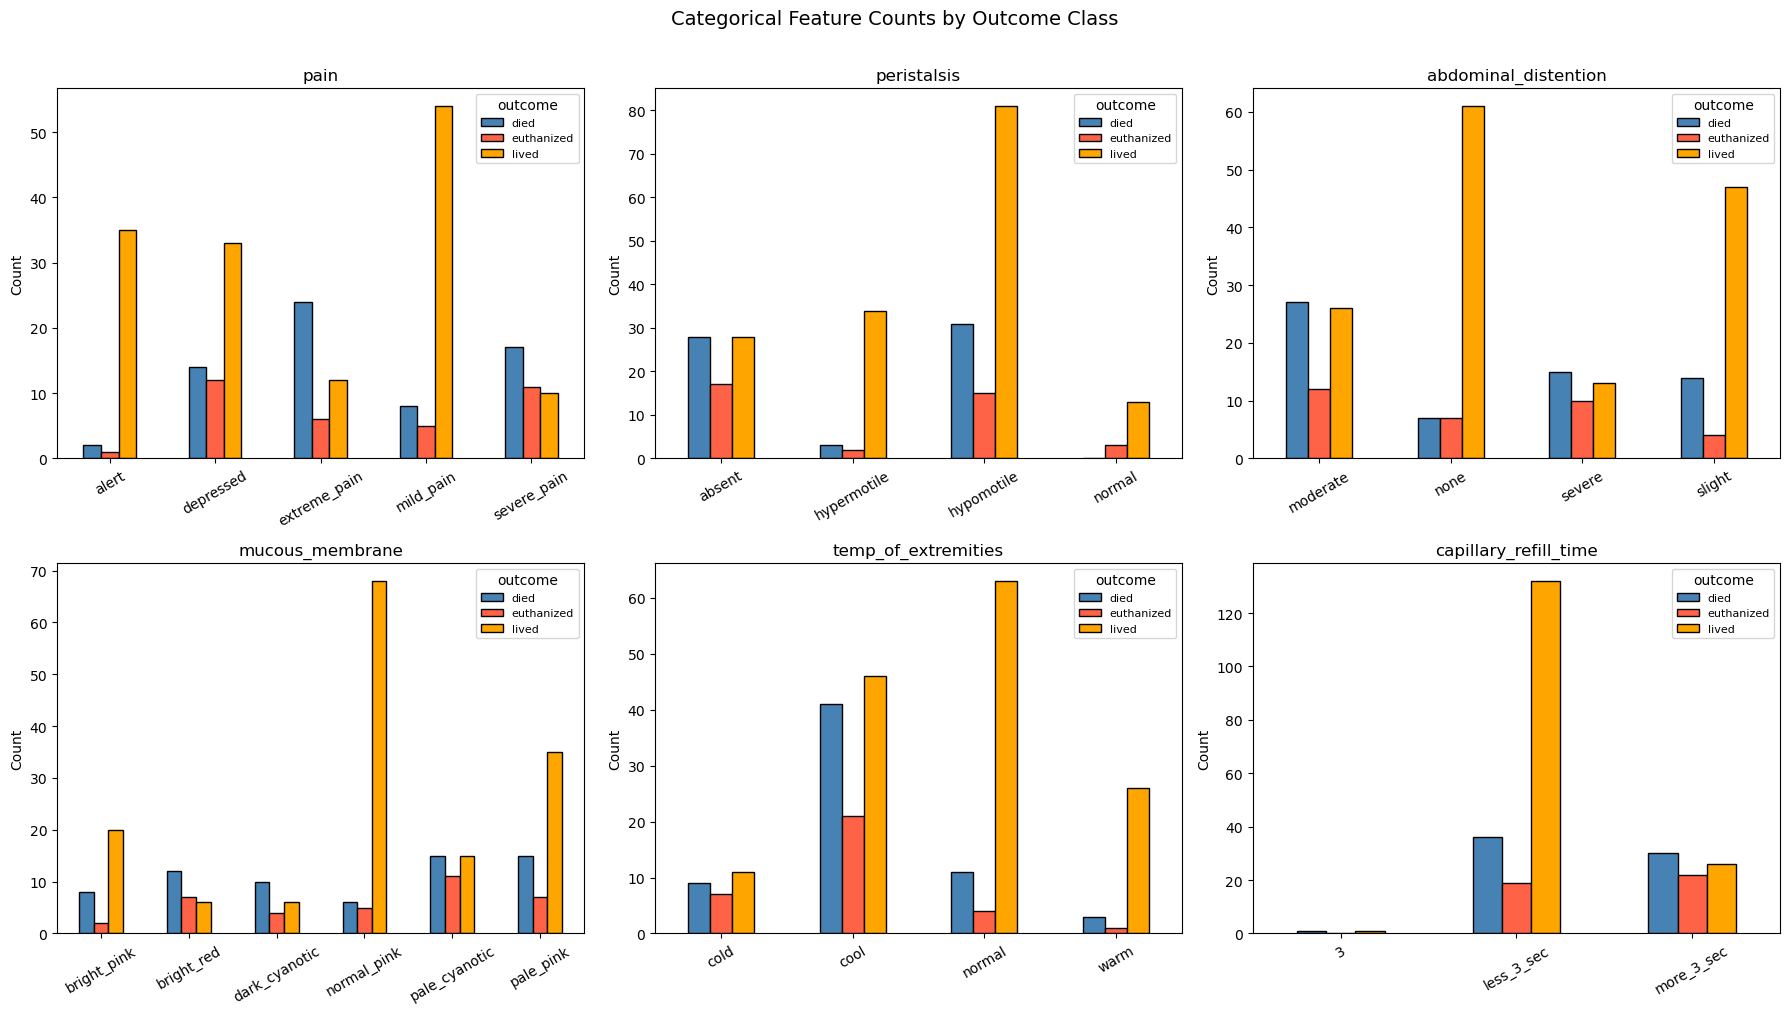

In [8]:
# Counting plots of key categorical features by outcome
cat_cols_viz = ['pain', 'peristalsis', 'abdominal_distention', 'mucous_membrane',
                'temp_of_extremities', 'capillary_refill_time']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_viz):
    ax = axes[i]
    ct = df.groupby([col, 'outcome']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax,
            color=['steelblue','tomato','orange'], edgecolor='black')
    ax.set_title(col); ax.set_xlabel(''); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='outcome', fontsize=8)

plt.suptitle('Categorical Feature Counts by Outcome Class', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

In [9]:
df_clean = df.copy()

# Dropping hospital_number — row identifier with no predictive value
df_clean.drop(columns=['hospital_number'], inplace=True)

# Dropping lesion_2 and lesion_3 — overwhelmingly 0, near-zero variance
df_clean.drop(columns=['lesion_2', 'lesion_3'], inplace=True)

# Dropping nasogastric_reflux_ph, abdomo_protein, abdomo_appearance — >55% missing,
# too sparse to impute reliably
df_clean.drop(columns=['nasogastric_reflux_ph', 'abdomo_protein', 'abdomo_appearance'],
              inplace=True)

print("Remaining columns:", df_clean.columns.tolist())
print("Shape:", df_clean.shape)

Remaining columns: ['surgery', 'age', 'rectal_temp', 'pulse', 'respiratory_rate', 'temp_of_extremities', 'peripheral_pulse', 'mucous_membrane', 'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distention', 'nasogastric_tube', 'nasogastric_reflux', 'rectal_exam_feces', 'abdomen', 'packed_cell_volume', 'total_protein', 'outcome', 'surgical_lesion', 'lesion_1', 'cp_data']
Shape: (299, 22)


In [10]:
# Imputing categorical features with mode
cat_cols_clean = [c for c in df_clean.columns
                  if not pd.api.types.is_numeric_dtype(df_clean[c]) and c != 'outcome']

print("Imputing categorical features (mode):")
for col in cat_cols_clean:
    n_missing = df_clean[col].isnull().sum()
    if n_missing == 0:
        continue
    mode_val = df_clean[col].mode()[0]
    df_clean[col].fillna(mode_val, inplace=True)
    print(f"  {col}: filled {n_missing} NaN -> '{mode_val}'")

Imputing categorical features (mode):
  temp_of_extremities: filled 56 NaN -> 'cool'
  peripheral_pulse: filled 69 NaN -> 'normal'
  mucous_membrane: filled 47 NaN -> 'normal_pink'
  capillary_refill_time: filled 32 NaN -> 'less_3_sec'
  pain: filled 55 NaN -> 'mild_pain'
  peristalsis: filled 44 NaN -> 'hypomotile'
  abdominal_distention: filled 56 NaN -> 'none'
  nasogastric_tube: filled 104 NaN -> 'slight'
  nasogastric_reflux: filled 106 NaN -> 'none'
  rectal_exam_feces: filled 102 NaN -> 'absent'
  abdomen: filled 118 NaN -> 'distend_large'


In [11]:
# Imputing numerical features with median
num_cols_clean = [c for c in df_clean.columns if pd.api.types.is_numeric_dtype(df_clean[c])]

print("Imputing numerical features (median):")
for col in num_cols_clean:
    n_missing = df_clean[col].isnull().sum()
    if n_missing == 0:
        continue
    med = df_clean[col].median()
    df_clean[col].fillna(med, inplace=True)
    print(f"  {col}: filled {n_missing} NaN -> median={med:.2f}")

Imputing numerical features (median):
  rectal_temp: filled 60 NaN -> median=38.20
  pulse: filled 24 NaN -> median=64.00
  respiratory_rate: filled 58 NaN -> median=25.00
  packed_cell_volume: filled 29 NaN -> median=45.00
  total_protein: filled 33 NaN -> median=7.50


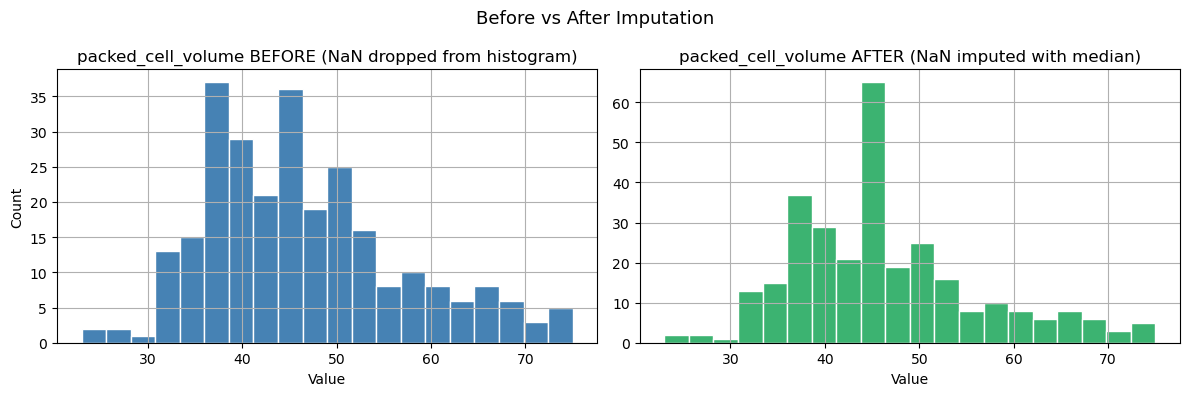

In [12]:
# Visualizing a numerical feature before/after imputation (packed_cell_volume)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['packed_cell_volume'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('packed_cell_volume BEFORE (NaN dropped from histogram)')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Count')

df_clean['packed_cell_volume'].hist(bins=20, ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('packed_cell_volume AFTER (NaN imputed with median)')
axes[1].set_xlabel('Value')

plt.suptitle('Before vs After Imputation', fontsize=13)
plt.tight_layout(); plt.show()

In [13]:
# One-hot encode categorical features
df_encoded = pd.get_dummies(df_clean, columns=cat_cols_clean, drop_first=False)
print("Shape after one-hot encoding:", df_encoded.shape)
df_encoded.head(2)

Shape after one-hot encoding: (299, 60)


,rectal_temp,pulse,respiratory_rate,packed_cell_volume,total_protein,outcome,lesion_1,surgery_no,surgery_yes,age_adult,...,rectal_exam_feces_normal,abdomen_distend_large,abdomen_distend_small,abdomen_firm,abdomen_normal,abdomen_other,surgical_lesion_no,surgical_lesion_yes,cp_data_no,cp_data_yes
0,38.5,66.0,28.0,45.0,8.4,died,11300,True,False,True,...,False,True,False,False,False,False,True,False,True,False
1,39.2,88.0,20.0,50.0,85.0,euthanized,2208,False,True,True,...,False,False,False,False,False,True,True,False,True,False


In [14]:
# Encoding target
label_map = {'lived': 0, 'died': 1, 'euthanized': 2}
df_encoded['outcome'] = df_encoded['outcome'].map(label_map)
print("Target encoding:", label_map)
print(df_encoded['outcome'].value_counts())

Target encoding: {'lived': 0, 'died': 1, 'euthanized': 2}
outcome
0    178
1     77
2     44
Name: count, dtype: int64


In [15]:
# Machine Learning

# Original categorical columns have already been replaced by their one-hot dummies.
# hospital_number (row ID) and the near-constant lesion_2, lesion_3 were dropped earlier.
# Target: outcome — encoded as 0=lived, 1=died, 2=euthanized.
# We split into train / validation / test = 60% / 20% / 20%, stratified on the target.
# Numerical features are scaled with StandardScaler fit on the training set only, then applied to validation and test (to avoid data leakage).

# Took help from claude to organize this

In [17]:
# Separating features and target
X = df_encoded.drop(columns=['outcome'])
y = df_encoded['outcome']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

Feature matrix shape: (299, 59)
Target shape: (299,)

Class distribution:
outcome
0    178
1     77
2     44
Name: count, dtype: int64


In [18]:
# Train / Validation / Test split  (60% / 20% / 20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train:      {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test:       {X_test.shape[0]} samples")

Train:      179 samples
Validation: 60 samples
Test:       60 samples


In [21]:
# Rescaling numerical features, fitting on TRAIN ONLY, then transforming val/test
num_cols_to_scale = ['rectal_temp', 'pulse', 'respiratory_rate',
                     'packed_cell_volume', 'total_protein', 'lesion_1']

scaler = StandardScaler()
X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_val[num_cols_to_scale]   = scaler.transform(X_val[num_cols_to_scale])
X_test[num_cols_to_scale]  = scaler.transform(X_test[num_cols_to_scale])

print("Scaled features (training set summary):")
X_train[num_cols_to_scale].describe().round(2)

Scaled features (training set summary):


,rectal_temp,pulse,respiratory_rate,packed_cell_volume,total_protein,lesion_1
count,179.00,179.00,179.00,179.00,179.00,179.00
mean,0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-4.25,-1.48,-1.33,-2.28,-0.72,-0.74
25%,-0.42,-0.81,-0.57,-0.69,-0.60,-0.30
50%,0.12,-0.23,-0.25,-0.09,-0.56,-0.10
75%,0.44,0.51,0.28,0.41,1.00,-0.08
max,4.18,4.18,4.24,2.70,2.58,5.71


In [23]:
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                            random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


In [24]:
y_val_pred = rf.predict(X_val)

acc = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_val_pred,
                            target_names=['lived','died','euthanized']))

Validation Accuracy: 0.7500

Classification Report:
              precision    recall  f1-score   support

       lived       0.77      0.92      0.84        36
        died       0.67      0.67      0.67        15
  euthanized       1.00      0.22      0.36         9

    accuracy                           0.75        60
   macro avg       0.81      0.60      0.62        60
weighted avg       0.78      0.75      0.72        60



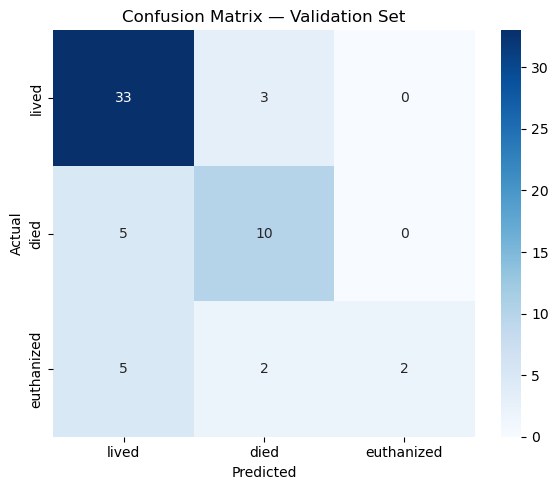

In [25]:
# Confusion matrix (validation)
cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['lived','died','euthanized'],
            yticklabels=['lived','died','euthanized'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Validation Set')
plt.tight_layout(); plt.show()

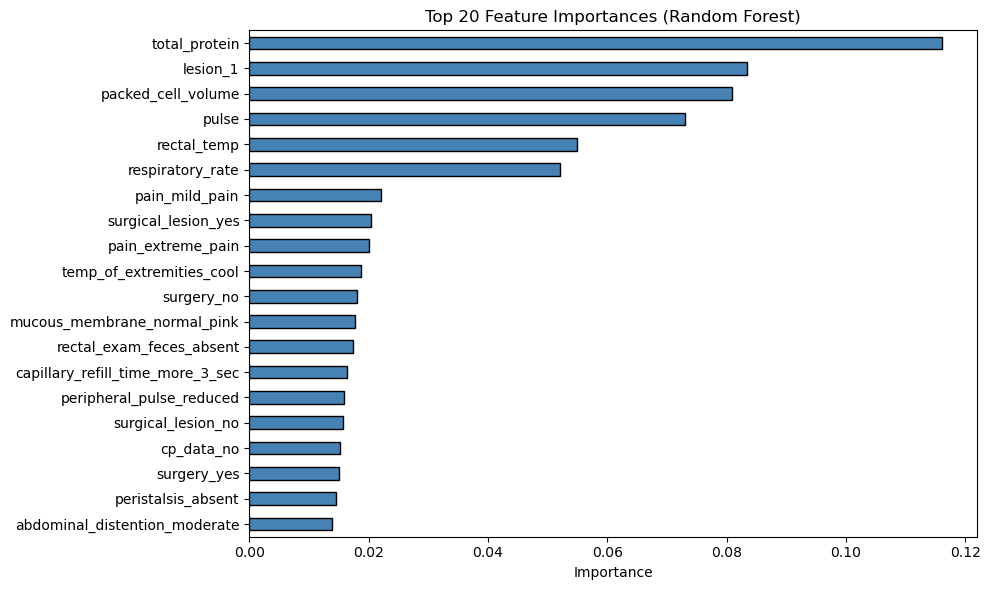

In [26]:
# Top 20 feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)\
                .sort_values(ascending=False)
top20 = importances.head(20)

plt.figure(figsize=(10, 6))
top20.plot(kind='barh', color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()

In [27]:
y_test_pred = rf.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}\n")
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred,
                            target_names=['lived','died','euthanized']))

Test Accuracy: 0.6333

Test Classification Report:
              precision    recall  f1-score   support

       lived       0.73      0.75      0.74        36
        died       0.55      0.73      0.63        15
  euthanized       0.00      0.00      0.00         9

    accuracy                           0.63        60
   macro avg       0.43      0.49      0.46        60
weighted avg       0.58      0.63      0.60        60



In [28]:
# Generating submission-style output
inv_map = {0:'lived', 1:'died', 2:'euthanized'}
submission = pd.DataFrame({
    'index': X_test.index,
    'predicted_outcome': y_test_pred,
    'predicted_label': pd.Series(y_test_pred).map(inv_map).values
})
submission.to_csv('horse_submission.csv', index=False)
print("Submission file saved as horse_submission.csv")
submission.head(10)

Submission file saved as horse_submission.csv


,index,predicted_outcome,predicted_label
0,126,0,lived
1,286,0,lived
2,285,1,died
3,256,0,lived
4,275,0,lived
5,182,0,lived
6,5,0,lived
7,292,0,lived
8,180,0,lived
9,214,0,lived


In [29]:
# Overall, I used claude to help me organize the code and debug it wherever necessary. I often struggled with parts or planning the code, and I turned to claude to ask what code I could use and why. It gave me suggestions and helped me by providing the code for projects on similar datasets.